# Time series 15: Tuned blend vs naive vs persistence+delta

Uses the **same time period as time_series_14**: last 30% of data as test (60/10/30 train/val/test split, same low-pass filter). All three models are compared on that test window only, so naive and P+delta metrics match ts14.

- **Tuned blend**: Predictions from `data/time_series/tuned_blend_predictions.parquet`, restricted to the ts14 test window.
- **Naive**: Persistence only — previous value (same as ts14).
- **Persistence + hour delta**: Previous value + δ(hour) fitted on training (same as ts14).
- **Metrics**: MAE, RMSE, and MASE for all three (MASE = MAE(model) / MAE(naive), so naive has MASE = 1).

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent

BLEND_PATH = _root / "data" / "time_series" / "tuned_blend_predictions.parquet"
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found: {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
N = len(freq_bands)
Z = df[freq_bands].values.astype(np.float64)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
hours = df["hour"].values.astype(int)
T_total = Z.shape[0]

# Same split and filter as time_series_14 — evaluate only on test (last 30%)
train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
n_train = int(T_total * train_ratio)
n_val = int(T_total * val_ratio)
n_test = T_total - n_train - n_val
test_start = n_train + n_val

USE_LOWPASS = True
CUTOFF = 0.5
FILTER_ORDER = 3

def lowpass_per_channel(Z_mat, cutoff=0.5, order=3):
    from scipy.signal import butter, filtfilt
    normal_cutoff = min(float(cutoff), 0.99)
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    out = np.zeros_like(Z_mat)
    for j in range(Z_mat.shape[1]):
        out[:, j] = filtfilt(b, a, Z_mat[:, j])
    return out

if USE_LOWPASS:
    Z_full = lowpass_per_channel(Z, cutoff=CUTOFF, order=FILTER_ORDER)
    print(f"Applied low-pass filter (cutoff={CUTOFF}, order={FILTER_ORDER}).")
else:
    Z_full = Z.copy()

Z_train = Z_full[:n_train]
Z_test = Z_full[test_start:]
hours_train = hours[:n_train]
print(f"Train: {n_train}, Val: {n_val}, Test: {n_test} (same time period as ts14).")

# Fit delta per (channel, hour) on training
n_hours = 24
delta = np.zeros((N, n_hours))
for j in range(N):
    for h in range(n_hours):
        mask = (hours_train[1:] == h)
        if np.any(mask):
            diff = Z_train[1:, j] - Z_train[:-1, j]
            delta[j, h] = np.mean(diff[mask])

# Predictions on test only (last 30%): naive and persistence+delta — same logic as ts14
pred_naive = np.zeros((n_test, N), dtype=np.float64)
pred_pdelta = np.zeros((n_test, N), dtype=np.float64)
for t in range(n_test):
    prev_idx = test_start + t - 1 if t > 0 else test_start - 1
    pred_naive[t] = Z_full[prev_idx]
    h = hours[test_start + t]
    if h < 0 or h >= n_hours:
        h = 0
    for j in range(N):
        pred_pdelta[t, j] = Z_full[prev_idx, j] + delta[j, h]

# Test datetimes only (same window as ts14)
test_datetimes = df["datetime"].iloc[test_start:].values

# Build long-format table for test window only
rows = []
for t in range(n_test):
    dt = test_datetimes[t]
    for j in range(N):
        rows.append({
            "datetime": pd.Timestamp(dt),
            "frequency_band": freq_bands[j],
            "actual": float(Z_test[t, j]),
            "naive_pred": float(pred_naive[t, j]),
            "pdelta_pred": float(pred_pdelta[t, j]),
        })
compare_df = pd.DataFrame(rows)

# Add blend predictions — restrict to test window so all three use same time period
if BLEND_PATH.exists():
    blend = pd.read_parquet(BLEND_PATH)
    blend["datetime"] = pd.to_datetime(blend["datetime"])
    blend_test = blend[blend["datetime"].isin(compare_df["datetime"].unique())][["datetime", "frequency_band", "predicted"]].rename(columns={"predicted": "blend_pred"})
    compare_df = compare_df.merge(blend_test, on=["datetime", "frequency_band"], how="left")
    n_blend = compare_df["blend_pred"].notna().sum()
    print(f"Blend loaded; {n_blend} rows in test window have blend predictions.")
else:
    compare_df["blend_pred"] = np.nan
    print("Tuned blend parquet not found; blend metrics will be omitted.")

print(f"Comparison table: {len(compare_df)} rows (test window = last 30%, {n_test} hours × {N} bands — same as ts14).")

Applied low-pass filter (cutoff=0.5, order=3).
Train: 5515, Val: 919, Test: 2758 (same time period as ts14).
Blend loaded; 193060 rows in test window have blend predictions.
Comparison table: 193060 rows (test window = last 30%, 2758 hours × 70 bands — same as ts14).


## Metrics: MAE, RMSE, MASE for all three models

In [11]:
def mae_rmse(actual, pred):
    actual = np.asarray(actual).astype(float)
    pred = np.asarray(pred).astype(float)
    mae = float(np.mean(np.abs(actual - pred)))
    rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
    return mae, rmse

y = compare_df["actual"].values.astype(float)
y_naive = compare_df["naive_pred"].values.astype(float)
y_pdelta = compare_df["pdelta_pred"].values.astype(float)

mae_naive, rmse_naive = mae_rmse(y, y_naive)
mae_pdelta, rmse_pdelta = mae_rmse(y, y_pdelta)
# MASE = MAE(model) / MAE(naive); naive has MASE = 1
mase_naive = 1.0
mase_pdelta = mae_pdelta / (mae_naive + 1e-12)

print("Naive (persistence only):")
print(f"  MAE  = {mae_naive:.4f},  RMSE = {rmse_naive:.4f},  MASE = {mase_naive:.4f}")
print("Persistence + hour delta:")
print(f"  MAE  = {mae_pdelta:.4f},  RMSE = {rmse_pdelta:.4f},  MASE = {mase_pdelta:.4f}")

if compare_df["blend_pred"].notna().any():
    mask = compare_df["blend_pred"].notna()
    y_b = compare_df.loc[mask, "actual"].values.astype(float)
    y_blend = compare_df.loc[mask, "blend_pred"].values.astype(float)
    mae_blend, rmse_blend = mae_rmse(y_b, y_blend)
    mase_blend = mae_blend / (mae_naive + 1e-12)
    print("Tuned blend (on same test window):")
    print(f"  MAE  = {mae_blend:.4f},  RMSE = {rmse_blend:.4f},  MASE = {mase_blend:.4f}")
    print(f"  (evaluated on {mask.sum()} rows where blend predictions exist)")
else:
    mae_blend = rmse_blend = mase_blend = np.nan
    print("Tuned blend: no predictions in test window (parquet missing or no overlap).")

Naive (persistence only):
  MAE  = 2.7672,  RMSE = 4.5277,  MASE = 1.0000
Persistence + hour delta:
  MAE  = 2.3127,  RMSE = 3.8167,  MASE = 0.8358
Tuned blend (on same test window):
  MAE  = 3.1780,  RMSE = 5.5308,  MASE = 1.1484
  (evaluated on 193060 rows where blend predictions exist)


## Comparison table and bar charts (MAE, RMSE, MASE)

           Method      MAE     RMSE     MASE
            Naive 2.767170 4.527694 1.000000
Persistence+delta 2.312688 3.816711 0.835759
      Tuned blend 3.177956 5.530784 1.148450


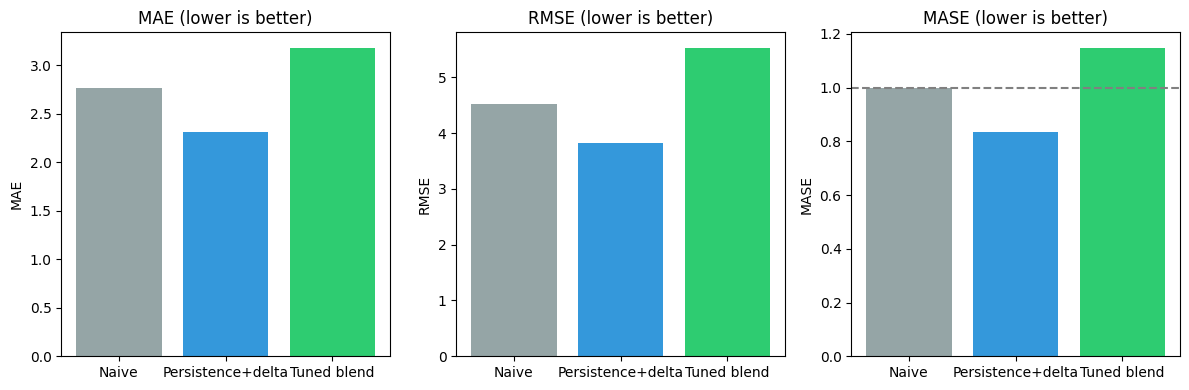

In [12]:
import matplotlib.pyplot as plt

methods = ["Naive", "Persistence+delta"]
maes = [mae_naive, mae_pdelta]
rmses = [rmse_naive, rmse_pdelta]
mases = [mase_naive, mase_pdelta]
if not np.isnan(mae_blend):
    methods.append("Tuned blend")
    maes.append(mae_blend)
    rmses.append(rmse_blend)
    mases.append(mase_blend)

tab = pd.DataFrame({
    "Method": methods,
    "MAE": maes,
    "RMSE": rmses,
    "MASE": mases,
})
print(tab.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
x = np.arange(len(methods))
axes[0].bar(x, maes, color=["#95a5a6", "#3498db", "#2ecc71"][: len(methods)])
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE (lower is better)")
axes[1].bar(x, rmses, color=["#95a5a6", "#3498db", "#2ecc71"][: len(methods)])
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE (lower is better)")
axes[2].bar(x, mases, color=["#95a5a6", "#3498db", "#2ecc71"][: len(methods)])
axes[2].axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods)
axes[2].set_ylabel("MASE")
axes[2].set_title("MASE (lower is better)")
plt.tight_layout()
plt.show()